# Importación de librerías y carga de datos

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

sns.set_theme(style="whitegrid")

ruta_kaggle = './../../dataset/kaggle/student_performance.csv'
df_kaggle = pd.read_csv(ruta_kaggle)

print(f"Dataset de Kaggle cargado. Dimensiones: {df_kaggle.shape}")
df_kaggle.head()

Dataset de Kaggle cargado. Dimensiones: (1000000, 6)


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


# Creación de la variable objetivo

C:\Users\joseb\AppData\Local\Temp\ipykernel_10028\2647365689.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df_modelo, palette=['#2ECC71', '#E74C3C'])


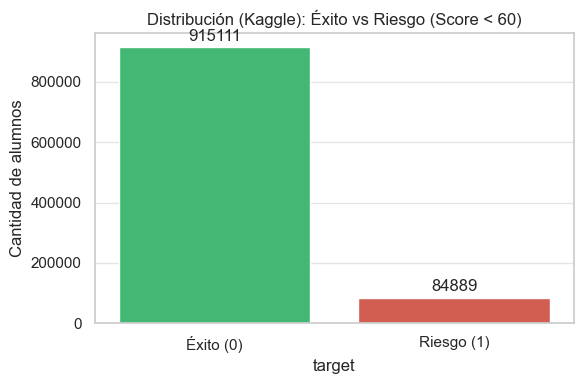

In [14]:
umbral_aprobado = 60
df_kaggle['target'] = df_kaggle['total_score'].apply(lambda x: 1 if x < umbral_aprobado else 0)

cols_to_drop = ['student_id', 'total_score', 'grade']
df_modelo = df_kaggle.drop(columns=cols_to_drop)

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df_modelo, palette=['#2ECC71', '#E74C3C'])
plt.title(f'Distribución (Kaggle): Éxito vs Riesgo (Score < {umbral_aprobado})')
plt.xticks(ticks=[0, 1], labels=['Éxito (0)', 'Riesgo (1)'])
plt.ylabel('Cantidad de alumnos')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

# Preprocesamiento y partición

In [15]:
X = df_modelo.drop(columns=['target'])
y = df_modelo['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Características utilizadas: {list(X.columns)}")
print(f"Entrenamiento: {X_train_scaled.shape[0]} registros.")
print(f"Prueba: {X_test_scaled.shape[0]} registros.")

Características utilizadas: ['weekly_self_study_hours', 'attendance_percentage', 'class_participation']
Entrenamiento: 800000 registros.
Prueba: 200000 registros.


# Entrenamiento del modelo

In [16]:
modelo_rf_kaggle = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

modelo_rf_kaggle.fit(X_train_scaled, y_train)
y_pred_kaggle = modelo_rf_kaggle.predict(X_test_scaled)

print("Entrenamiento y predicción sobre dataset Kaggle completados.")

KeyboardInterrupt: 

# Charts

--- REPORTE DE CLASIFICACIÓN (KAGGLE) ---
              precision    recall  f1-score   support

   Éxito (0)       0.92      0.98      0.95    183022
  Riesgo (1)       0.08      0.02      0.03     16978

    accuracy                           0.90    200000
   macro avg       0.50      0.50      0.49    200000
weighted avg       0.84      0.90      0.87    200000



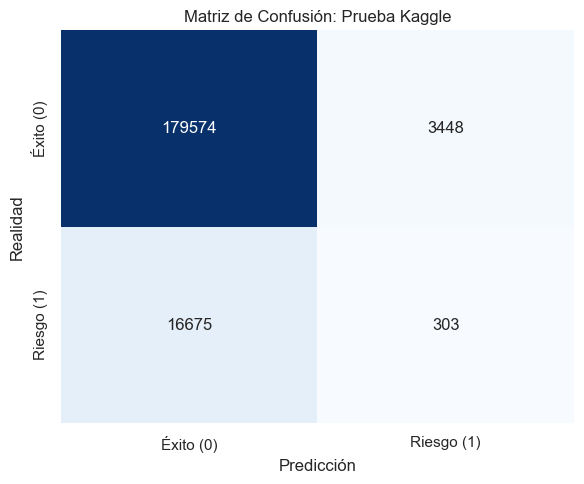

C:\Users\joseb\AppData\Local\Temp\ipykernel_10028\1423426877.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=metricas_todas_k, y=valores_todos_k, palette='viridis')


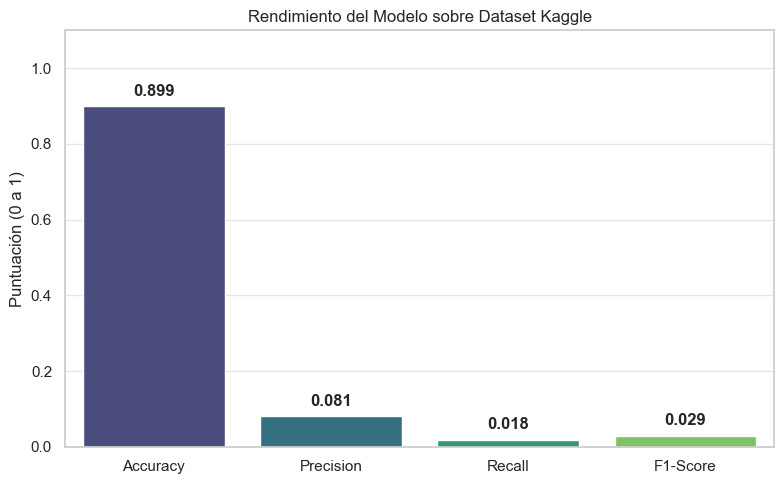

In [17]:
print("--- REPORTE DE CLASIFICACIÓN (KAGGLE) ---")
print(classification_report(y_test, y_pred_kaggle, target_names=['Éxito (0)', 'Riesgo (1)']))

plt.figure(figsize=(6, 5))
cm_kaggle = confusion_matrix(y_test, y_pred_kaggle)
sns.heatmap(cm_kaggle, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])

plt.title('Matriz de Confusión: Prueba Kaggle')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.tight_layout()
plt.show()

acc_k = accuracy_score(y_test, y_pred_kaggle)
prec_k = precision_score(y_test, y_pred_kaggle, zero_division=0)
rec_k = recall_score(y_test, y_pred_kaggle, zero_division=0)
f1_k = f1_score(y_test, y_pred_kaggle, zero_division=0)

plt.figure(figsize=(8, 5))
metricas_todas_k = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores_todos_k = [acc_k, prec_k, rec_k, f1_k]

ax2 = sns.barplot(x=metricas_todas_k, y=valores_todos_k, palette='viridis')
plt.title('Rendimiento del Modelo sobre Dataset Kaggle')
plt.ylim(0, 1.1)
plt.ylabel('Puntuación (0 a 1)')

for i, v in enumerate(valores_todos_k):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()